In [ ]:
# script to generate plots related to COSMIC analysis

In [47]:
# import packages
import pandas as pd
import matplotlib.pyplot as mpl
import seaborn as sns
from scipy import stats
import math
import numpy as np
import os
from tqdm import tqdm
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import PrecisionRecallDisplay
from sklearn import metrics
from collections import Counter
import forestplot as fp
import statsmodels.api as sm
from tqdm import tqdm
import matplotlib.patches as mpatches
pd.set_option('display.max_columns', None)

In [48]:
# change to cosmic data directory
os.chdir('/Users/buttsj/Dropbox (JAX)/Variant_Effects/cosmic/')

In [49]:
# open COSMIC predictions
cosmic_preds_no_act = pd.read_csv('/Users/buttsj/Dropbox (JAX)/Variant_Effects/cosmic/all.cosmic.v98.autosome.snps.annotated.017.031925.txt',
                           sep = '\t')

In [50]:
# add emVar status to predictions - no activity threshold, abs(skew) >= .5
# define function to add max ref/alt activities for a prediction DF for easier acitivity filtering
def add_max_act (pred_df):
    # k562
    pred_df['k562_max_act'] = [max([i,j], key=abs) for i,j in zip(pred_df['k562_ref_pred'],
                                                                  pred_df['k562_alt_pred'])]
    # hepg2
    pred_df['hepg2_max_act'] = [max([i,j], key=abs) for i,j in zip(pred_df['hepg2_ref_pred'],
                                                                   pred_df['hepg2_alt_pred'])]
    # sknsh
    pred_df['sknsh_max_act'] = [max([i,j], key=abs) for i,j in zip(pred_df['sknsh_ref_pred'],
                                                                   pred_df['sknsh_alt_pred'])]
    # add activity binary
    pred_df['k562_active'] = ['+' if abs(i) >= 1 else '-' for i in pred_df['k562_max_act']]
    pred_df['hepg2_active'] = ['+' if abs(i) >= 1 else '-' for i in pred_df['hepg2_max_act']]
    pred_df['sknsh_active'] = ['+' if abs(i) >= 1 else '-' for i in pred_df['sknsh_max_act']]
    return pred_df
# define function to return emVar status - with activity
def add_act_emvar (pred_df,
                   cell_type,
                   skew_cutoff):
    # make a list for emvar status
    emvar_list = []
    for active, skew in zip(pred_df[f'{cell_type}_active'],
                             pred_df[f'{cell_type}_skew_pred']):
        if active == '+' and abs(skew) >= skew_cutoff:
            emvar_list.append('+')
        else:
            emvar_list.append('-')
    # add column to DF
    pred_df[f'{cell_type}_emvar'] = emvar_list
    return pred_df
# define function to return emVar status - without activity
def add_emvar (pred_df,
               cell_type,
               skew_cutoff):
    # make a list for emvar status
    emvar_list = []
    for skew in pred_df[f'{cell_type}_skew_pred']:
        if abs(skew) >= skew_cutoff:
            emvar_list.append('+')
        else:
            emvar_list.append('-')
    # add column to DF
    pred_df[f'{cell_type}_emvar'] = emvar_list
    return pred_df
# annotate emVars in predictions - with activity filter
def annotate_act_preds (df,
                        skew_thresh):
    # add max activity
    df = add_max_act(df)
    # add k562 emVar status
    df = add_act_emvar(df,
                   'k562',
                   skew_thresh)
    # add hepg2 emVar status
    df = add_act_emvar(df,
                   'hepg2',
                   skew_thresh)
    # add sknsh emVar status
    df = add_act_emvar(df,
                   'sknsh',
                   skew_thresh)
    # add emVar any column
    df['emvar_any'] = ['+' if [i,j,k].count('+') > 0 else '-' for i,j,k in zip(df['k562_emvar'],
                                                                               df['hepg2_emvar'],
                                                                               df['sknsh_emvar'])]
    return df
# annotate emVars in predictions - without activity filter
def annotate_preds (df,
                    skew_thresh):
    # add max activity
    df = add_max_act(df)
    # add k562 emVar status
    df = add_emvar(df,
                   'k562',
                   skew_thresh)
    # add hepg2 emVar status
    df = add_emvar(df,
                   'hepg2',
                   skew_thresh)
    # add sknsh emVar status
    df = add_emvar(df,
                   'sknsh',
                   skew_thresh)
    # add emVar any column
    df['emvar_any'] = ['+' if [i,j,k].count('+') > 0 else '-' for i,j,k in zip(df['k562_emvar'],
                                                                               df['hepg2_emvar'],
                                                                               df['sknsh_emvar'])]
    # add mean activity column
    df['mean_ref_act'] = [np.mean([k,h,s]) for k,h,s in zip(df['k562_ref_pred'],
                                                            df['hepg2_ref_pred'],
                                                            df['sknsh_ref_pred'])]
    # add mean skew column
    df['mean_skew'] = [np.mean([k,h,s]) for k,h,s in zip(df['k562_skew_pred'],
                                                         df['hepg2_skew_pred'],
                                                         df['sknsh_skew_pred'])]
    return df 

In [51]:
# define function to calculate odds ratios
# does not account for activity - filter for activity if desired
# not set up for multiple variates, pre-filter DF for that
# eg filter full DF for only 250bp promoters and then use recurrence to compare recurrent v unique promoter variants
### Function to make 2x2 table for scipy.stats.fisher_exact
def two_by_two_table (pos_list, neg_list):
    df = pd.DataFrame()
    df.index = ['Variants in Bin', 'Non-Bin Variants']
    df['Positive'] = pos_list
    df['Negative'] = neg_list
    return df
# define function to add 95% confidence interval to oddsR DFs, return DF of oddsR emVar, pval test, confidence interval, bin
def add_confidence (two_by_table,
                    bar_df,
                    variate):
    try:
        # break out 2 x 2 table into a,b,c,d
        a = two_by_table['Positive'].tolist()[0]
        b = two_by_table['Negative'].tolist()[0]
        c = two_by_table['Positive'].tolist()[1]
        d = two_by_table['Negative'].tolist()[1]
        # get oddsR from bar df
        oddsR = bar_df['OddsR'].tolist()[0]
        # get p_val from bar df
        p_val = bar_df['p_val'].tolist()[0]
        # calculate upper/lower 95% confidence intervals
        upper_95 = math.e**(np.log(oddsR) + 1.96 * np.sqrt(1/a + 1/b + 1/c + 1/d))
        lower_95 = math.e**(np.log(oddsR) - 1.96 * np.sqrt(1/a + 1/b + 1/c + 1/d))
        # make a df with oddsR, p value, and confidence interval
        out_df = pd.DataFrame({'OddsR' : [oddsR],
                               'p_val' : [p_val],
                               'round_p' : [np.round(p_val,4)],
                               'upperCI' : [upper_95],
                               'lowerCI' : [lower_95],
                               'label' : [variate]}, index=[variate])
    except ZeroDivisionError:
        out_df = pd.DataFrame({'OddsR' : [oddsR],
                               'p_val' : [p_val],
                               'round_p' : [np.round(p_val,4)],
                               'upperCI' : [np.NaN],
                               'lowerCI' : [np.NaN], 
                               'label' : [variate]}, index=[variate])
        
    return out_df
def oddsR_calculator(df,
                     column_of_interest,
                     emvar_col):
    # filter full df into positive and negative for given variate
    # pos df
    pos_df = df[df[column_of_interest] == '+']
    # neg df
    neg_df = df[df[column_of_interest] == '-']
    # count emVars in each group
    # pos
    pos_emvars = pos_df[emvar_col].tolist().count('+')
    # neg
    neg_emvars = neg_df[emvar_col].tolist().count('+')
    # get difference of emvars and non-emvars in each group
    # pos
    pos_non_emvars = len(pos_df) - pos_emvars
    # neg
    neg_non_emvars = len(neg_df) - neg_emvars
    # make a 2 x 2 table
    twoBytwo_table = two_by_two_table([pos_emvars, pos_non_emvars],
                                      [neg_emvars, neg_non_emvars])
    # calculate oddsR and p value
    oddsR, pval = stats.fisher_exact(twoBytwo_table)
    # make a DF for storing info
    odds_df = pd.DataFrame({'OddsR' : [oddsR],
                            'p_val' : [pval]})
    # add confidence intervals to df
    oddsR_ci_df = add_confidence(twoBytwo_table,
                                 odds_df,
                                 column_of_interest)
    print(column_of_interest)
    print(oddsR)
    print(pval)
    return oddsR_ci_df, twoBytwo_table;
# additional confidence interval function
# define function to add 95% confidence interval to oddsR DFs, return DF of oddsR emVar, pval test, confidence interval, bin
def add_confidence_bin (two_by_table,
                        df2pass,
                        feature,
                        bin):
    try:
        # break out 2 x 2 table into a,b,c,d
        a = two_by_table[0].tolist()[0]
        b = two_by_table[1].tolist()[0]
        c = two_by_table[0].tolist()[1]
        d = two_by_table[1].tolist()[1]
        # get oddsR from bar df
        oddsR = df2pass['oddsR'].tolist()[0]
        # get p_val from bar df
        p_val = df2pass['p_val'].tolist()[0]
        # calculate upper/lower 95% confidence intervals
        upper_95 = math.e**(np.log(oddsR) + 1.96 * np.sqrt(1/a + 1/b + 1/c + 1/d))
        lower_95 = math.e**(np.log(oddsR) - 1.96 * np.sqrt(1/a + 1/b + 1/c + 1/d))
        # make a df with oddsR, p value, and confidence interval
        out_df = pd.DataFrame({'Feature' : [feature],
                               'Bin' : [bin],
                               'OddsR' : [oddsR],
                               'p_val' : [p_val],
                               'round_p' : [np.round(p_val,2)],
                               'upperCI' : [upper_95],
                               'lowerCI' : [lower_95]})
    except ZeroDivisionError:
        out_df = pd.DataFrame({'Feature' : [feature],
                               'Bin' : [bin],
                               'OddsR' : [oddsR],
                               'p_val' : [p_val],
                               'round_p' : [np.round(p_val,2)],
                               'upperCI' : [np.NaN],
                               'lowerCI' : [np.NaN]})
        
    return out_df

In [52]:
# define function to calculate odds ratio of a variant being recurrent by activity bin
def oddsR_emvar_by_act_bin_max (preds_df): # must have mean reference activity and and activity bins added
    # make dict for storing feature information 
    dfs2concat = []
    recurrent = preds_df[preds_df['recurrent'] == '+']
    unique = preds_df[preds_df['recurrent'] != '+']
    # iterate through list of bins and get oddsR with 95 CI and return a DF for plotting
    for bin in preds_df['max_act_bin'].unique():
        # filter full df for only that bin
        bin_r = recurrent[recurrent['max_act_bin'] == bin]
        bin_1 = unique[unique['max_act_bin'] == bin]
        # add emvars
        # recurrent
        bin_r['bin_emvar'] = ['+' if abs(i) > .5 else '-' for i in bin_r['max_skew']]
        # unique
        bin_1['bin_emvar'] = ['+' if abs(i) > .5 else '-' for i in bin_1['max_skew']]
        # make a 2x2 table for that bin
        two_by_two = pd.DataFrame({0 : [bin_r['bin_emvar'].tolist().count('+'), # count number of emvars in that bin
                                        len(recurrent) - bin_r['bin_emvar'].tolist().count('+')],
                                   1 : [bin_1['bin_emvar'].tolist().count('+'), # count number of emvars in that bin
                                        len(unique) - bin_1['bin_emvar'].tolist().count('+')]})
        print(bin)
        print(two_by_two)
        # calculate odds ratio
        oddsr_path_emvar, pval_path_emvar = stats.fisher_exact(two_by_two)
        # make a DF
        df2pass = pd.DataFrame({'feature' : ['emVar'],
                              'oddsR' : [oddsr_path_emvar],
                              'p_val' : [pval_path_emvar]})
        # calculate 95% CI
        conf_df = add_confidence_bin(two_by_two,
                                     df2pass,
                                     'emVar',
                                     bin)
        conf_df['label'] = [str(i) for i in conf_df['Bin']]
        conf_df['n_recurrent_emvars'] = [bin_r['bin_emvar'].tolist().count('+')]
        # update df list with df
        dfs2concat.append(conf_df)
    # combine dfs into single df with all bins
    all_bins = pd.concat(dfs2concat).reset_index().sort_values(by='Bin')
    return all_bins

In [53]:
# add emvar annotations, without activity threshold, to predictions
cosmic_preds_no_act = annotate_preds(cosmic_preds_no_act,
                             .5)

In [54]:
# count number of recurrent emvars
# in promoters
n_recurrent_pro_emvars = len(cosmic_preds_no_act[(cosmic_preds_no_act['emvar_any'] == '+') &
                                                 (cosmic_preds_no_act['recurrent'] == '+') &
                                                 (cosmic_preds_no_act['250bp_promoter'] == '+')])
print(f'The number of recurrent promoter emVars is {n_recurrent_pro_emvars}')
# out of promoters
n_recurrent_emvars_noPro = len(cosmic_preds_no_act[(cosmic_preds_no_act['emvar_any'] == '+') &
                                                 (cosmic_preds_no_act['recurrent'] == '+') &
                                                 (cosmic_preds_no_act['250bp_promoter'] == '-')])
print(f'The number of recurrent non-promoter emVars is {n_recurrent_emvars_noPro}')

The number of recurrent promoter emVars is 117
The number of recurrent non-promoter emVars is 1775


In [55]:
# add columns for recurrent promoter and recurrent cnc promoter
cosmic_preds_no_act['recurrent_250bp_promoter'] = ['+' if i == '+' and j == '+' else '-' for i,j in zip(cosmic_preds_no_act['recurrent'],
                                                                                                        cosmic_preds_no_act['250bp_promoter'])]
cosmic_preds_no_act['recurrent_cnc_promoter'] = ['+' if i == '+' and j == '+' else '-' for i,j in zip(cosmic_preds_no_act['recurrent'],
                                                                                                      cosmic_preds_no_act['cnc_database_250bp_promoter'])]
# plot activity distribution of recurrent vs unique variants
# add mean skew
cosmic_preds_no_act['mean_ref_activity'] = [np.mean([k,h,s]) for k,h,s in zip(cosmic_preds_no_act['k562_ref_pred'],
                                                                          cosmic_preds_no_act['hepg2_ref_pred'],
                                                                          cosmic_preds_no_act['sknsh_ref_pred'])]
cosmic_preds_no_act['mean_alt_activity'] = [np.mean([k,h,s]) for k,h,s in zip(cosmic_preds_no_act['k562_alt_pred'],
                                                                          cosmic_preds_no_act['hepg2_alt_pred'],
                                                                          cosmic_preds_no_act['sknsh_alt_pred'])]
# add K562 max activity
cosmic_preds_no_act['k562_max_activity'] = [max([k_r, k_a], key=abs) for k_r, k_a in zip(cosmic_preds_no_act['k562_ref_pred'],
                                                                                         cosmic_preds_no_act['k562_alt_pred'])]
# add HepG2 max activity
cosmic_preds_no_act['hepg2_max_activity'] = [max([h_r, h_a], key=abs) for h_r, h_a in zip(cosmic_preds_no_act['hepg2_ref_pred'],
                                                                                          cosmic_preds_no_act['hepg2_alt_pred'])]
# add SKNSH max activity
cosmic_preds_no_act['sknsh_max_activity'] = [max([s_r, s_a], key=abs) for s_r, s_a in zip(cosmic_preds_no_act['sknsh_ref_pred'],
                                                                                          cosmic_preds_no_act['sknsh_alt_pred'])]

# annotate activity ranges
cosmic_preds_no_act['mean_ref_bin'] = pd.cut(cosmic_preds_no_act['mean_ref_activity'], [float('-inf'), 1, 2, 3, 4, 5, float('inf')])
cosmic_preds_no_act['k562_act_bin'] = pd.cut(cosmic_preds_no_act['k562_max_activity'], [float('-inf'), 1, 2, 3, 4, 5, float('inf')])
cosmic_preds_no_act['hepg2_act_bin'] = pd.cut(cosmic_preds_no_act['hepg2_max_activity'], [float('-inf'), 1, 2, 3, 4, 5, float('inf')])
cosmic_preds_no_act['sknsh_act_bin'] = pd.cut(cosmic_preds_no_act['sknsh_max_activity'], [float('-inf'), 1, 2, 3, 4, 5, float('inf')])

In [56]:
# define function to assign max skew and activity bin
def reformat_df4act_bin (df):
    # get cell type of max skew
    max_skew_cell = []
    max_skew_l2fc = []
    for k_skew, h_skew, s_skew in zip(df['k562_skew_pred'],
                                      df['hepg2_skew_pred'],
                                      df['sknsh_skew_pred']):
        skew_list = [k_skew, h_skew, s_skew]
        max_skew = max([k_skew, h_skew, s_skew], key=abs)
        if skew_list[0] == max_skew:
            max_skew_cell.append('k562')
            max_skew_l2fc.append(max_skew)
        elif skew_list[1] == max_skew:
            max_skew_cell.append('hepg2')
            max_skew_l2fc.append(max_skew)
        elif skew_list[2] == max_skew:
            max_skew_cell.append('sknsh')
            max_skew_l2fc.append(max_skew)
    df['max_skew_cell'] = max_skew_cell
    # get matching activity bin
    k_act_bin = df['k562_act_bin'].tolist()
    h_act_bin = df['hepg2_act_bin'].tolist()
    s_act_bin = df['sknsh_act_bin'].tolist()
    act_bin = []
    for i,j in tqdm(zip(range(len(df)),
                   df['max_skew_cell'])):
        if j == 'k562':
            act_bin.append(k_act_bin[i])
        elif j == 'hepg2':
            act_bin.append(h_act_bin[i])
        elif j == 'sknsh':
            act_bin.append(s_act_bin[i])
        #act_bin.append(df[f'{j}_act_bin'].tolist()[i])
    df['max_act_bin'] = act_bin
    # return skew of max cell type
    df['max_skew'] = max_skew_l2fc
    return df

In [57]:
cosmic_preds_no_act = reformat_df4act_bin(cosmic_preds_no_act)

2432725it [00:00, 6502128.19it/s]


In [58]:
# calculate oddsR an emVar is recurrent by activity bin
recurrent_emvar_or_by_act = oddsR_emvar_by_act_bin_max(cosmic_preds_no_act)

(3.0, 4.0]
       0        1
0    138     3530
1  66775  2362282
(5.0, inf]
       0        1
0    179      858
1  66734  2364954
(4.0, 5.0]
       0        1
0     70     1244
1  66843  2364568
(-inf, 1.0]
       0        1
0    365    12207
1  66548  2353605
(1.0, 2.0]
       0        1
0    752    22802
1  66161  2343010
(2.0, 3.0]
       0        1
0    388     9757
1  66525  2356055


In [59]:
# calculate oddsR an emVar is recurrent by activity bin - no promoters
recurrent_emvar_or_by_act_no_pro = oddsR_emvar_by_act_bin_max(cosmic_preds_no_act[cosmic_preds_no_act['250bp_promoter'] == '-'])

(3.0, 4.0]
       0        1
0    131     3421
1  66293  2356516
(5.0, inf]
       0        1
0     84      639
1  66340  2359298
(4.0, 5.0]
       0        1
0     61     1130
1  66363  2358807
(-inf, 1.0]
       0        1
0    365    12195
1  66059  2347742
(1.0, 2.0]
       0        1
0    747    22735
1  65677  2337202
(2.0, 3.0]
       0        1
0    387     9667
1  66037  2350270


In [60]:
# calculate oddsR an emVar is recurrent by activity bin - no promoters, in DHS
recurrent_emvar_or_by_act_no_pro_in_dhs = oddsR_emvar_by_act_bin_max(cosmic_preds_no_act[(cosmic_preds_no_act['250bp_promoter'] == '-') &
                                                                                               (cosmic_preds_no_act['DHS_meuleman'] == '+')])

(3.0, 4.0]
       0       1
0     79    2217
1  19375  613960
(-inf, 1.0]
       0       1
0    158    4333
1  19296  611844
(1.0, 2.0]
       0       1
0    377   10882
1  19077  605295
(2.0, 3.0]
       0       1
0    204    5614
1  19250  610563
(4.0, 5.0]
       0       1
0     46     796
1  19408  615381
(5.0, inf]
       0       1
0     77     529
1  19377  615648


In [61]:
# calculate oddsR an emVar is recurrent by activity bin - in promoter
recurrent_emvar_or_by_act_250_pro = oddsR_emvar_by_act_bin_max(cosmic_preds_no_act[cosmic_preds_no_act['250bp_promoter'] == '+'])

(1.0, 2.0]
     0     1
0    5    67
1  484  5808
(2.0, 3.0]
     0     1
0    1    90
1  488  5785
(4.0, 5.0]
     0     1
0    9   114
1  480  5761
(5.0, inf]
     0     1
0   95   219
1  394  5656
(3.0, 4.0]
     0     1
0    7   109
1  482  5766
(-inf, 1.0]
     0     1
0    0    12
1  489  5863


In [62]:
# calculate odds ratios and confidence intervals for plotting
# no activity filter for emVars
non_pro_oddsr_ci_df, non_pro_2x2 = oddsR_calculator(cosmic_preds_no_act[cosmic_preds_no_act['250bp_promoter'] == '-'],
                                                   'recurrent',
                                                    'emvar_any')
# recurrent vs unique variants
recurrent_oddsr_ci_df, recurrent2x2 = oddsR_calculator(cosmic_preds_no_act,
                                                       'recurrent',
                                                       'emvar_any')
# promoter vs non-promoter variants
twoFifty_pro_oddsr_ci_df, twoFiftypro2x2 = oddsR_calculator(cosmic_preds_no_act,
                                                            '250bp_promoter',
                                                            'emvar_any')
# promoter vs non-promoter variants - no CNC
twoFifty_pro_oddsr_ci_df_no_CNC, twoFiftypro2x2_no_CNC = oddsR_calculator(cosmic_preds_no_act[cosmic_preds_no_act['cnc_database_250bp_promoter'] == '-'],
                                                            '250bp_promoter',
                                                            'emvar_any')
# cnc 250bp promoter vs other promoters
cnc_twoFifty_oddsr_ci_df, cnc2x2 = oddsR_calculator(cosmic_preds_no_act,
                                                    'cnc_database_250bp_promoter',
                                                    'emvar_any')
# compare recurrent promoter variants to unique promoter variants
recurrent_promoter_oddsr_ci_df, rec_pro2x2 = oddsR_calculator(cosmic_preds_no_act, # filter full active set for only promoter variants
                                                              'recurrent_250bp_promoter',
                                                              'emvar_any')
# compare recurrent cnc promoter variants to unique promoter variants
recurrent_cnc_pro_oddsr_ci_df, rec_cnc_2x2 = oddsR_calculator(cosmic_preds_no_act, # filter full active set for only cnc promoter variants
                                                              'recurrent_cnc_promoter',
                                                              'emvar_any')
# concatenate all together
cat_odds_or = pd.concat([recurrent_oddsr_ci_df,
                     twoFifty_pro_oddsr_ci_df,
                     cnc_twoFifty_oddsr_ci_df,
                     recurrent_promoter_oddsr_ci_df,
                     recurrent_cnc_pro_oddsr_ci_df])
# add a column to concatenated df with label for y axis on plot below
cat_odds_or['plot_labs'] = ['Recurrent',
                            '250bp Promoter',
                            'CNC Promoter',
                            'Recurrent Promoter',
                            'Recurrent CNC Promoter']
# define a color palette for recurrence, etc.
feature_palette = {'recurrent' : '#1F271B',
                   'Recurrent' : '#1F271B',
                   '250bp_promoter' : "#19647E",
                   '250bp Promoter' : "#19647E",
                   'cnc_database_250bp_promoter' : "turquoise",
                   'CNC Promoter' : "turquoise",
                   'recurrent_250bp_promoter' : "#F4D35E",
                   'Recurrent Promoter' : "#F4D35E",
                   'recurrent_cnc_promoter' : "#EE964B",
                   'Recurrent CNC Promoter' : "#EE964B"}

recurrent
1.2739745957759017
1.2049744508500503e-21
recurrent
1.3368504921095379
9.759020154778131e-32
250bp_promoter
5.949185321390148
2.3371699480244052e-288
250bp_promoter
5.790484770073942
9.445881277295879e-261
cnc_database_250bp_promoter
8.855627649035126
4.1279786989200025e-31
recurrent_250bp_promoter
14.34780828422562
6.81100349932403e-84
recurrent_cnc_promoter
16.180736950866923
9.184661531408822e-22


In [65]:
# make a figure describing activity differences for recurrent vs unique variants
# split predictions into recurrent and unique
recurrent_cosmic = cosmic_preds_no_act[cosmic_preds_no_act['recurrent'] == '+']

In [66]:
# plot TERT promoter mutations
# -124 COSV57196518
# -146 COSV57196531
# filter full cosmic predictions for TERT promoter mutations
tert_pro_muts = cosmic_preds_no_act[cosmic_preds_no_act['id'].isin(['COSV57196518',
                                                      'COSV57196531'])]
# reformat -124 preds df for plotting
# activity
minus124_act_df = pd.DataFrame({'Activity' : [tert_pro_muts['k562_ref_pred'].tolist()[0],
                                              tert_pro_muts['k562_alt_pred'].tolist()[0],
                                              tert_pro_muts['hepg2_ref_pred'].tolist()[0],
                                              tert_pro_muts['hepg2_alt_pred'].tolist()[0],
                                              tert_pro_muts['sknsh_ref_pred'].tolist()[0],
                                              tert_pro_muts['sknsh_alt_pred'].tolist()[0]],
                                'Prediction' : ['K562 Ref',
                                                'K562 Alt',
                                                'HepG2 Ref',
                                                'HepG2 Alt',
                                                'SKNSH Ref',
                                                'SKNSH Alt'],
                                'TERT Promoter Mutation' : ['-124 C>T' for i in range(6)]})
# skew
minus124_skew_df = pd.DataFrame({'Skew' : [tert_pro_muts['k562_skew_pred'].tolist()[0],
                                               tert_pro_muts['hepg2_skew_pred'].tolist()[0],
                                               tert_pro_muts['sknsh_skew_pred'].tolist()[0]],
                                 'Prediction' : ['K562',
                                                 'HepG2',
                                                 'SKNSH'],
                                 'TERT Promoter Mutation' : ['-124 C>T' for i in range(3)]})
# reformat -146
minus146_act_df = pd.DataFrame({'Activity' : [tert_pro_muts['k562_ref_pred'].tolist()[1],
                                              tert_pro_muts['k562_alt_pred'].tolist()[1],
                                              tert_pro_muts['hepg2_ref_pred'].tolist()[1],
                                              tert_pro_muts['hepg2_alt_pred'].tolist()[1],
                                              tert_pro_muts['sknsh_ref_pred'].tolist()[1],
                                              tert_pro_muts['sknsh_alt_pred'].tolist()[1]],
                                'Prediction' : ['K562 Ref',
                                                'K562 Alt',
                                                'HepG2 Ref',
                                                'HepG2 Alt',
                                                'SKNSH Ref',
                                                'SKNSH Alt'],
                                'TERT Promoter Mutation' : ['-146 C>T' for i in range(6)]})
# skew
minus146_skew_df = pd.DataFrame({'Skew' : [tert_pro_muts['k562_skew_pred'].tolist()[1],
                                               tert_pro_muts['hepg2_skew_pred'].tolist()[1],
                                               tert_pro_muts['sknsh_skew_pred'].tolist()[1]],
                                 'Prediction' : ['K562',
                                                 'HepG2',
                                                 'SKNSH'],
                                 'TERT Promoter Mutation' : ['-146 C>T' for i in range(3)]})
# combine activity dfs into one
tert_pro_activity_df = pd.concat([minus124_act_df,
                                  minus146_act_df])
# combine skew dfs into one
tert_pro_skew_df = pd.concat([minus124_skew_df,
                              minus146_skew_df])
# get mean skews for each mutation
mean_skew_124 = np.mean(tert_pro_skew_df[tert_pro_skew_df['TERT Promoter Mutation'] == '-124 C>T']['Skew'])
mean_skew_146 = np.mean(tert_pro_skew_df[tert_pro_skew_df['TERT Promoter Mutation'] == '-146 C>T']['Skew'])
# make a new DF for plotting 
tert_mean_skew = pd.DataFrame({'Skew' : [mean_skew_124, mean_skew_146],
                               'TERT Promoter Mutation' : ['-124 C>T', '-146 C>T']})
# define a color palette for plotting bar plot
bar_palette = {'K562' : '#00A79D',
              'HepG2' : '#FBB040',
              'SKNSH' : '#ED1C24'}

In [69]:
# plot feature by skew decile similar to Stephen's
# begin without considering activity
# add mean skew
cosmic_preds_no_act['mean_skew'] = [np.mean([k,h,s]) for k,h,s in zip(cosmic_preds_no_act['k562_skew_pred'],
                                                               cosmic_preds_no_act['hepg2_skew_pred'],
                                                               cosmic_preds_no_act['sknsh_skew_pred'])]

# get quantiles of mean skew
cosmic_preds_no_act['mean_skew_quantile'] = pd.qcut(cosmic_preds_no_act['mean_skew'], [0,.1,.2,.3,.4,.5,.6,.7,.8,.9,1])
# annotate skew ranges
cosmic_preds_no_act['mean_skew_bin'] = pd.cut(cosmic_preds_no_act['mean_skew'], [float('-inf'), -1.5, -1, -.5, -.2, -.05, .05, .2, .5, 1, 1.5, float('inf')])

In [70]:
# define a function to visualize features by skew bin
def oddsR_feature_by_skew_bin_all (preds_df, # requires mean skew to be calculated and col named 'mean_skew'
                               list_of_bins,
                               feature,
                               feature_ann):
    # add bin info to full df
    preds_df['mean_skew_bin'] = pd.cut(preds_df['mean_skew'], list_of_bins)
    # make dict for storing feature information 
    dfs2concat = []
    print(feature)
    # iterate through list of bins and get oddsR with 95 CI and return a DF for plotting
    for bin in preds_df['mean_skew_bin'].unique():
        # filter full df for only that bin
        bin_df = preds_df[preds_df['mean_skew_bin'] == bin]
        # make a 2x2 table for that bin
        two_by_two = pd.DataFrame({0 : [bin_df[feature].tolist().count('+'), # count number of feature variants in that bin
                                        (preds_df[feature].tolist().count('+') - bin_df[feature].tolist().count('+'))],
                                   1 : [bin_df[feature].tolist().count('-'), # count number of non-feature variants in that bin
                                        (preds_df[feature].tolist().count('-') - bin_df[feature].tolist().count('-'))]})
        # calculate odds ratio
        oddsr_path_emvar, pval_path_emvar = stats.fisher_exact(two_by_two)
        # make a DF
        df2pass = pd.DataFrame({'feature' : [feature_ann],
                              'oddsR' : [oddsr_path_emvar],
                              'p_val' : [pval_path_emvar]})
        # calculate 95% CI
        conf_df = add_confidence_bin(two_by_two,
                                     df2pass,
                                     feature_ann,
                                     bin)
        # log2 transform Odds Ratios to try and save plot space
        conf_df['log2_oddsR'] = [np.log2(i) for i in conf_df['OddsR']]
        conf_df['log2_lowerCI'] = [np.log2(i) for i in conf_df['lowerCI']]
        conf_df['log2_upperCI'] = [np.log2(i) for i in conf_df['upperCI']]
        # update df list with df
        dfs2concat.append(conf_df)
        print(bin)
        print(two_by_two)
    # combine dfs into single df with all bins
    all_bins = pd.concat(dfs2concat).reset_index().sort_values(by='Bin')
    return all_bins

In [71]:
# calculate oddsR by mean skew bin for each feature
# recurrent
recurrent_oddsR_by_bin = oddsR_feature_by_skew_bin_all(cosmic_preds_no_act,
                                                  [float('-inf'), -1, -.5, -.2, -.05, .05, .2, .5, 1, float('inf')],
                                                  'recurrent',
                                                  'Recurrent')
recurrent_oddsR_by_bin['label'] = [str(i) for i in recurrent_oddsR_by_bin['Bin']]
# recurrent non-promoter
recurrent_oddsR_by_bin_no_pro = oddsR_feature_by_skew_bin_all(cosmic_preds_no_act[cosmic_preds_no_act['250bp_promoter'] == '-'],
                                                              [float('-inf'), -1, -.5, -.2, -.05, .05, .2, .5, 1, float('inf')],
                                                              'recurrent',
                                                              'Recurrent: Non-Promoter')
recurrent_oddsR_by_bin_no_pro['label'] = [str(i) for i in recurrent_oddsR_by_bin_no_pro['Bin']]
# recurrent in DHS
recurrent_oddsR_by_bin_no_pro_in_dhs = oddsR_feature_by_skew_bin_all(cosmic_preds_no_act[(cosmic_preds_no_act['250bp_promoter'] == '-') &
                                                                                  (cosmic_preds_no_act['DHS_meuleman'] == '+')],
                                                              [float('-inf'), -1, -.5, -.2, -.05, .05, .2, .5, 1, float('inf')],
                                                              'recurrent',
                                                              'Recurrent: In DHS')
recurrent_oddsR_by_bin_no_pro_in_dhs['label'] = [str(i) for i in recurrent_oddsR_by_bin_no_pro_in_dhs['Bin']]
# 250bp promoter
twoFifty_oddsR_by_bin = oddsR_feature_by_skew_bin_all(cosmic_preds_no_act,
                                                  [float('-inf'), -1, -.5, -.2, -.05, .05, .2, .5, 1, float('inf')],
                                                  '250bp_promoter',
                                                  '250bp Promoter')
twoFifty_oddsR_by_bin['label'] = [str(i) for i in twoFifty_oddsR_by_bin['Bin']]
# CNC promoter
cnc_pro_oddsR_by_bin =  oddsR_feature_by_skew_bin_all(cosmic_preds_no_act,
                                                  [float('-inf'), -1, -.5, -.2, -.05, .05, .2, .5, 1, float('inf')],
                                                  'cnc_database_250bp_promoter',
                                                  'CNC Promoter')
cnc_pro_oddsR_by_bin['label'] = [str(i) for i in cnc_pro_oddsR_by_bin['Bin']]
# Promoter Recurrent
recurrent_promoter_OR_by_bin = oddsR_feature_by_skew_bin_all(cosmic_preds_no_act,
                                                        [float('-inf'), -1, -.5, -.2, -.05, .05, .2, .5, 1, float('inf')],
                                                        'recurrent_250bp_promoter',
                                                        'Recurrent Promoter')
recurrent_promoter_OR_by_bin['label'] = [str(i) for i in recurrent_promoter_OR_by_bin['Bin']]
# CNC Recurrent
recurrent_cnc_promoter_OR_by_bin = oddsR_feature_by_skew_bin_all(cosmic_preds_no_act,
                                                        [float('-inf'), -1, -.5, -.2, -.05, .05, .2, .5, 1, float('inf')],
                                                        'recurrent_cnc_promoter',
                                                        'Recurrent CNC Promoter')
recurrent_cnc_promoter_OR_by_bin['label'] = [str(i) for i in recurrent_cnc_promoter_OR_by_bin['Bin']]
bin_or_concat4view = pd.concat([recurrent_oddsR_by_bin,
                               twoFifty_oddsR_by_bin,
                               cnc_pro_oddsR_by_bin,
                                recurrent_promoter_OR_by_bin,
                               recurrent_cnc_promoter_OR_by_bin])


recurrent
(-0.05, 0.05]
       0        1
0  43477  1636017
1  23436   729795
(0.05, 0.2]
       0        1
0   7751   276711
1  59162  2089101
(-0.2, -0.05]
       0        1
0  11378   334199
1  55535  2031613
(0.2, 0.5]
       0        1
0   1216    40400
1  65697  2325412
(-0.5, -0.2]
       0        1
0   2113    53761
1  64800  2312051
(0.5, 1.0]
       0        1
0    260     7905
1  66653  2357907
(-1.0, -0.5]
       0        1
0    498    12002
1  66415  2353810
(-inf, -1.0]
       0        1
0    161     3211
1  66752  2362601
(1.0, inf]
       0        1
0     59     1606
1  66854  2364206
recurrent
(-0.05, 0.05]
       0        1
0  43331  1633595
1  23093   726342
(0.05, 0.2]
       0        1
0   7705   275741
1  58719  2084196
(-0.2, -0.05]
       0        1
0  11264   332862
1  55160  2027075
(0.2, 0.5]
       0        1
0   1200    40099
1  65224  2319838
(-0.5, -0.2]
       0        1
0   2016    53281
1  64408  2306656
(0.5, 1.0]
       0        1
0    257     7830
1

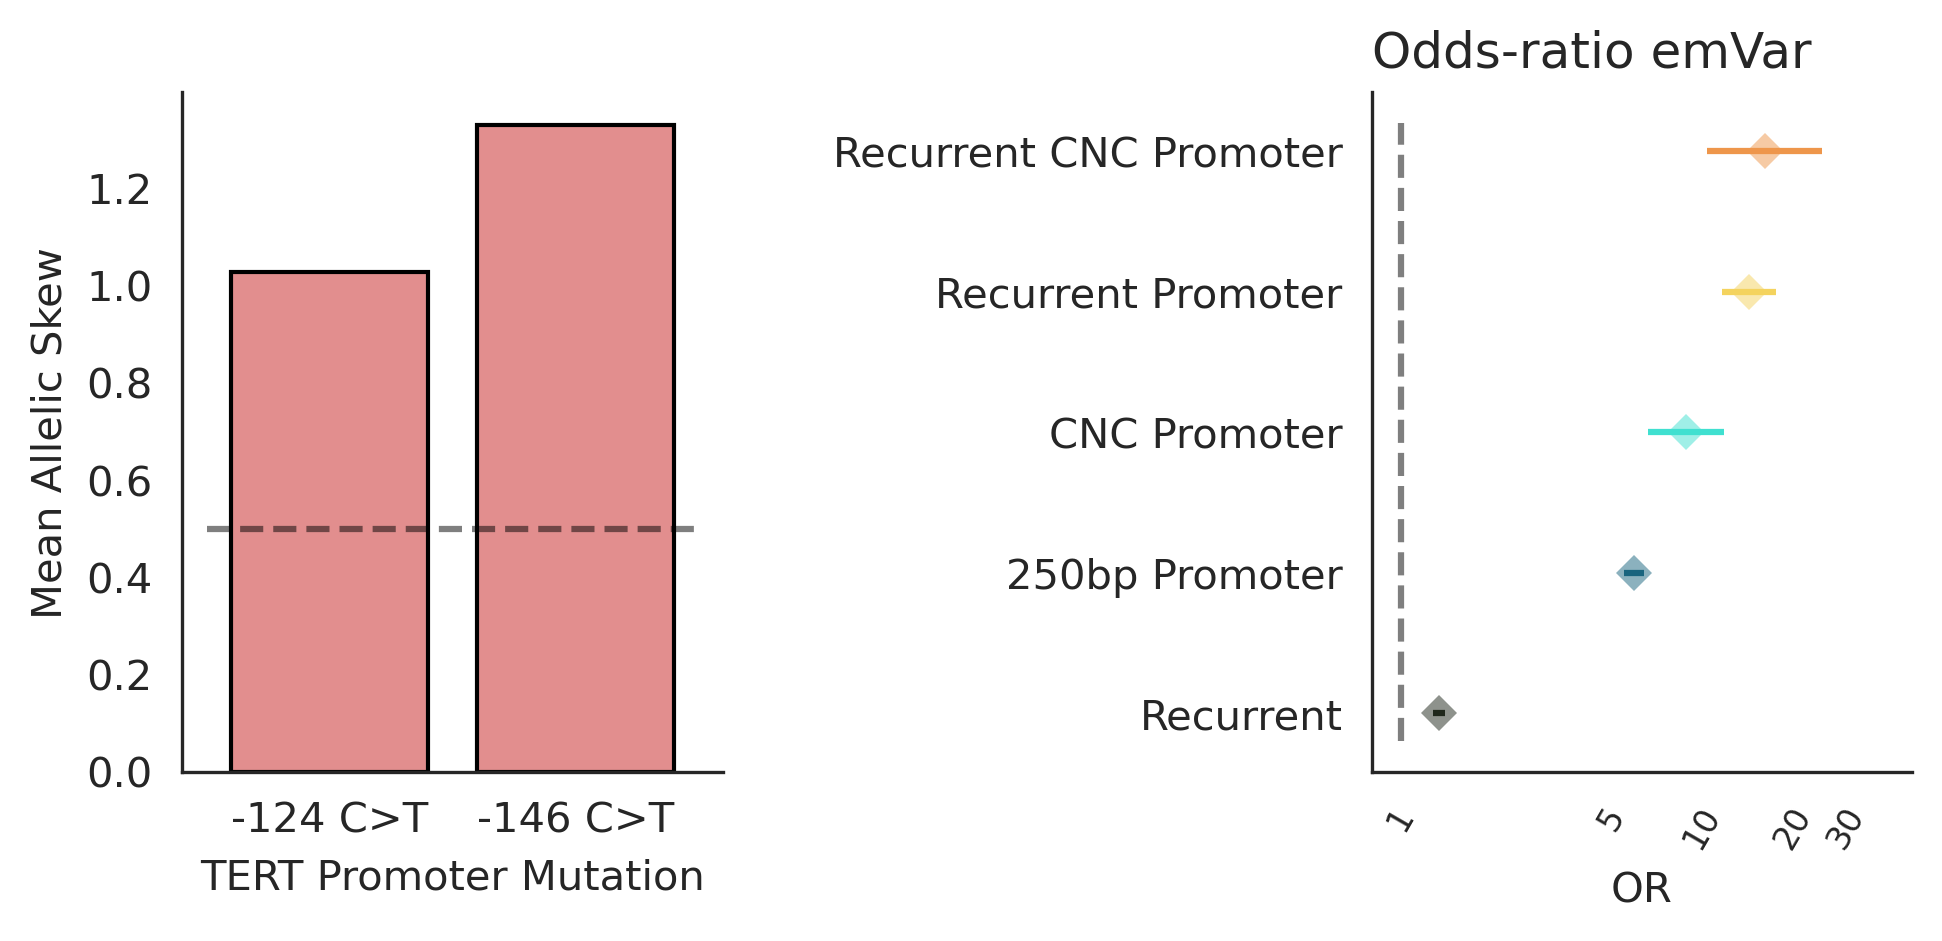

In [73]:
# plot top row of figure 2
# TERT promoter mutations
f = mpl.figure(figsize=(10, 3), dpi=300)
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42
gs = f.add_gridspec(1,4)
# add tert promoter skew
with sns.axes_style("white"):
    ax_01 = f.add_subplot(gs[0,0])
    sns.barplot(data=tert_mean_skew,
            x='TERT Promoter Mutation',
            y='Skew',
            color='lightcoral',
            edgecolor='k')
    xmin, xmax = ax_01.get_xlim()
    mpl.hlines(y=.5, xmin=xmin, xmax=xmax, color='k', alpha=.5, linestyle='dashed')
    mpl.ylabel('Mean Allelic Skew')
# add overall enrichments
with sns.axes_style("white"):
    ax_03 = f.add_subplot(gs[0, 2:3])
    ax_03.set_xscale('log')
    sns.pointplot(
        data=cat_odds_or.sort_values(by='OddsR', ascending = False), x="OddsR", y="plot_labs",
        palette=feature_palette, linestyle="none", marker="D", markersize=6, alpha=.5, linewidth=0
)
    mpl.ylabel('')
    for lower, upper, lab in zip(cat_odds_or['lowerCI'],
                                 cat_odds_or['upperCI'],
                                 cat_odds_or['plot_labs']):
        mpl.hlines(xmin=lower, xmax=upper, y=lab, color=feature_palette.get(lab))
    ymin, ymax = ax_03.get_ylim()
    mpl.vlines(x=1, ymin=ymin, ymax=ymax, color='k', alpha=.5, linestyle='dashed')
    mpl.title('Odds-ratio emVar', loc='left')
    mpl.xlabel('OR')
    mpl.xticks([1,5,10,20, 30], ['1','5','10', '20', '30'], rotation=60, size=8)
    mpl.xlim(.8, 50)
sns.despine()
mpl.subplots_adjust(wspace=.1, hspace=.3)
#mpl.savefig('/Users/buttsj/Dropbox (JAX)/Variant_Effects/final_plots_v2/cosmic/cosmic_row_1_tert_mean_skew_overall_enrichments.pdf', bbox_inches='tight')

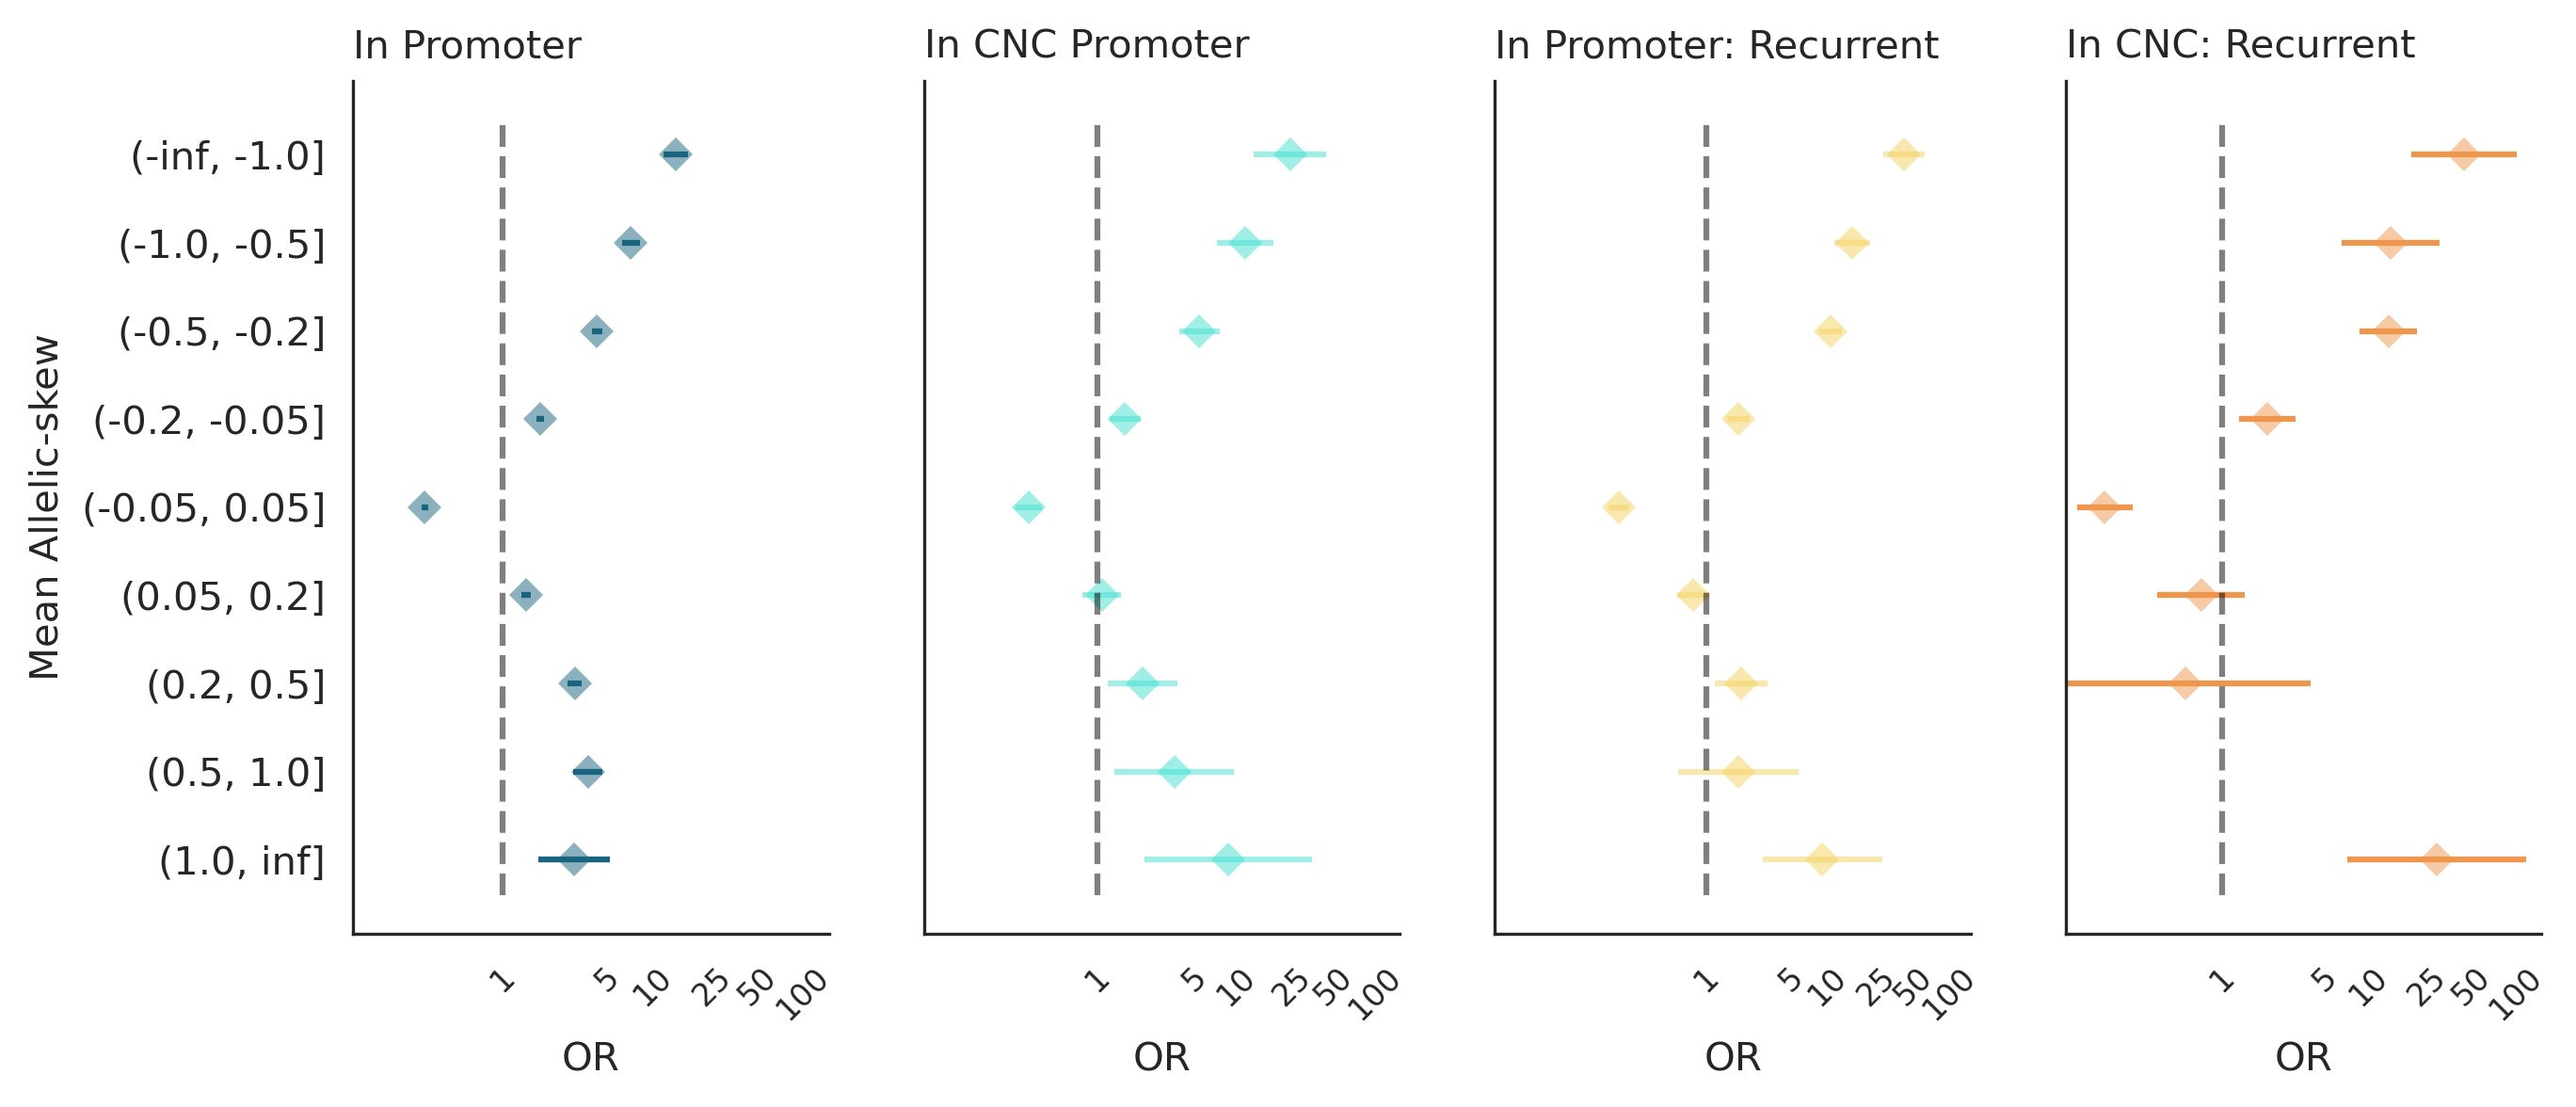

In [74]:
# plot middle row of figure 2
# promoter by skew bin all categories
f = mpl.figure(figsize=(10, 4), dpi=300)
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42
gs = f.add_gridspec(1, 4)
# promoter alone
with sns.axes_style("white"):
    ax1 = f.add_subplot(gs[0,0])
    ax1.set_xscale('log')
    sns.pointplot(
    data=twoFifty_oddsR_by_bin, x="OddsR", y="label",
    color="#19647E", linestyle="none", marker="D", markersize=6, alpha=.5, linewidth=0
)
    for lower, upper, lab in zip(twoFifty_oddsR_by_bin['lowerCI'],
                                 twoFifty_oddsR_by_bin['upperCI'],
                                 twoFifty_oddsR_by_bin['label']):
        mpl.hlines(xmin=lower, xmax=upper, y=lab, color='#19647E')
    ymin, ymax = ax1.get_ylim()
    mpl.ylabel('Mean Allelic-skew')
    mpl.vlines(x=1, ymin=ymin, ymax=ymax, color='k', alpha=.5, linestyle='dashed')
    mpl.xticks([1, 5, 10, 25, 50, 100], ['1','5','10', '25', '50', '100'], rotation=45, size=8)
    mpl.xlim(-1, 150)
    mpl.title('In Promoter', loc='left', size=10)
    mpl.xlabel('OR')
# cnc promoter
with sns.axes_style("white"):
    ax2 = f.add_subplot(gs[0,1])
    ax2.set_xscale('log')
    sns.pointplot(
    data=cnc_pro_oddsR_by_bin, x="OddsR", y="label",
    color="turquoise", linestyle="none", marker="D", markersize=6, alpha=.5, linewidth=0
)
    ax2.yaxis.set_visible(False)
    for lower, upper, lab in zip(cnc_pro_oddsR_by_bin['lowerCI'],
                                 cnc_pro_oddsR_by_bin['upperCI'],
                                 cnc_pro_oddsR_by_bin['label']):
        mpl.hlines(xmin=lower, xmax=upper, y=lab, color='turquoise', alpha=.5)
    ymin, ymax = ax2.get_ylim()
    mpl.vlines(x=1, ymin=ymin, ymax=ymax, color='k', alpha=.5, linestyle='dashed')
    mpl.xticks([1, 5, 10, 25, 50, 100], ['1','5','10', '25', '50', '100'], rotation=45, size=8)
    mpl.xlim(-1, 150)
    mpl.title('In CNC Promoter', loc='left', size=10)
    mpl.xlabel('OR')
# plot recurrent promoter
with sns.axes_style("white"):
    ax3 = f.add_subplot(gs[0,2])
    ax3.set_xscale('log')
    sns.pointplot(
    data=recurrent_promoter_OR_by_bin, x="OddsR", y="label",
    color="#F4D35E", linestyle="none", marker="D", markersize=6, alpha=.5, linewidth=0
)
    ax3.yaxis.set_visible(False)
    for lower, upper, lab in zip(recurrent_promoter_OR_by_bin['lowerCI'],
                                 recurrent_promoter_OR_by_bin['upperCI'],
                                 recurrent_promoter_OR_by_bin['label']):
        mpl.hlines(xmin=lower, xmax=upper, y=lab, color='#F4D35E', alpha=.5)
    mpl.vlines(x=1, ymin=ymin, ymax=ymax, color='k', alpha=.5, linestyle='dashed')
    mpl.xticks([1, 5, 10, 25, 50, 100], ['1','5','10', '25', '50', '100'], rotation=45, size=8)
    mpl.xlim(-1, 150)
    mpl.title('In Promoter: Recurrent', loc='left', size=10)
    mpl.xlabel('OR')
# plot recurrent cnc promoter
with sns.axes_style("white"):
    ax4 = f.add_subplot(gs[0,3])
    ax4.set_xscale('log')
    sns.pointplot(
    data=recurrent_cnc_promoter_OR_by_bin, x="OddsR", y="label",
    color="#EE964B", linestyle="none", marker="D", markersize=6, alpha=.5, linewidth=0
)
    ax4.yaxis.set_visible(False)
    for lower, upper, lab in zip(recurrent_cnc_promoter_OR_by_bin['lowerCI'],
                        recurrent_cnc_promoter_OR_by_bin['upperCI'],
                           recurrent_cnc_promoter_OR_by_bin['label']):
        mpl.hlines(xmin=lower, xmax=upper, y=lab, color='#EE964B')
    ymin, ymax = ax4.get_ylim()
    mpl.vlines(x=1, ymin=ymin, ymax=ymax, color='k', alpha=.5, linestyle='dashed')
    mpl.xticks([1, 5, 10, 25, 50, 100], ['1','5','10', '25', '50', '100'], rotation=45, size=8)
    mpl.xlim(-1, 150)
    mpl.title('In CNC: Recurrent', loc='left', size=10)
    mpl.xlabel('OR')
sns.despine()
#mpl.savefig('/Users/buttsj/Dropbox (JAX)/Variant_Effects/final_plots_v2/cosmic/promoter_skew_bin_row_all.pdf', bbox_inches='tight')

In [75]:
print(recurrent_oddsR_by_bin_no_pro_in_dhs)
# add label for plotting together
recurrent_oddsR_by_bin_no_pro_in_dhs['joint_lab'] = ['DHS' for i in range(len(recurrent_oddsR_by_bin_no_pro_in_dhs))]

   index            Feature            Bin     OddsR         p_val  round_p  \
7      0  Recurrent: In DHS   (-inf, -1.0]  1.765439  6.658408e-07     0.00   
3      0  Recurrent: In DHS   (-1.0, -0.5]  1.266242  3.802886e-04     0.00   
5      0  Recurrent: In DHS   (-0.5, -0.2]  1.283251  9.817473e-13     0.00   
2      0  Recurrent: In DHS  (-0.2, -0.05]  1.165233  4.037529e-17     0.00   
0      0  Recurrent: In DHS  (-0.05, 0.05]  0.869913  2.651700e-21     0.00   
1      0  Recurrent: In DHS    (0.05, 0.2]  0.952754  2.369555e-02     0.02   
6      0  Recurrent: In DHS     (0.2, 0.5]  1.008801  8.389512e-01     0.84   
4      0  Recurrent: In DHS     (0.5, 1.0]  1.052895  5.672247e-01     0.57   
8      0  Recurrent: In DHS     (1.0, inf]  0.865460  6.125641e-01     0.61   

    upperCI   lowerCI  log2_oddsR  log2_lowerCI  log2_upperCI          label  
7  2.171684  1.435189    0.820027      0.521240      1.118814   (-inf, -1.0]  
3  1.436604  1.116082    0.340553      0.158443    

In [29]:
print(recurrent_oddsR_by_bin_no_pro_in_dhs)

   index            Feature            Bin     OddsR         p_val  round_p  \
7      0  Recurrent: In DHS   (-inf, -1.0]  1.765439  6.658408e-07     0.00   
3      0  Recurrent: In DHS   (-1.0, -0.5]  1.266242  3.802886e-04     0.00   
5      0  Recurrent: In DHS   (-0.5, -0.2]  1.283251  9.817473e-13     0.00   
2      0  Recurrent: In DHS  (-0.2, -0.05]  1.165233  4.037529e-17     0.00   
0      0  Recurrent: In DHS  (-0.05, 0.05]  0.869913  2.651700e-21     0.00   
1      0  Recurrent: In DHS    (0.05, 0.2]  0.952754  2.369555e-02     0.02   
6      0  Recurrent: In DHS     (0.2, 0.5]  1.008801  8.389512e-01     0.84   
4      0  Recurrent: In DHS     (0.5, 1.0]  1.052895  5.672247e-01     0.57   
8      0  Recurrent: In DHS     (1.0, inf]  0.865460  6.125641e-01     0.61   

    upperCI   lowerCI  log2_oddsR  log2_lowerCI  log2_upperCI          label  \
7  2.171684  1.435189    0.820027      0.521240      1.118814   (-inf, -1.0]   
3  1.436604  1.116082    0.340553      0.158443  

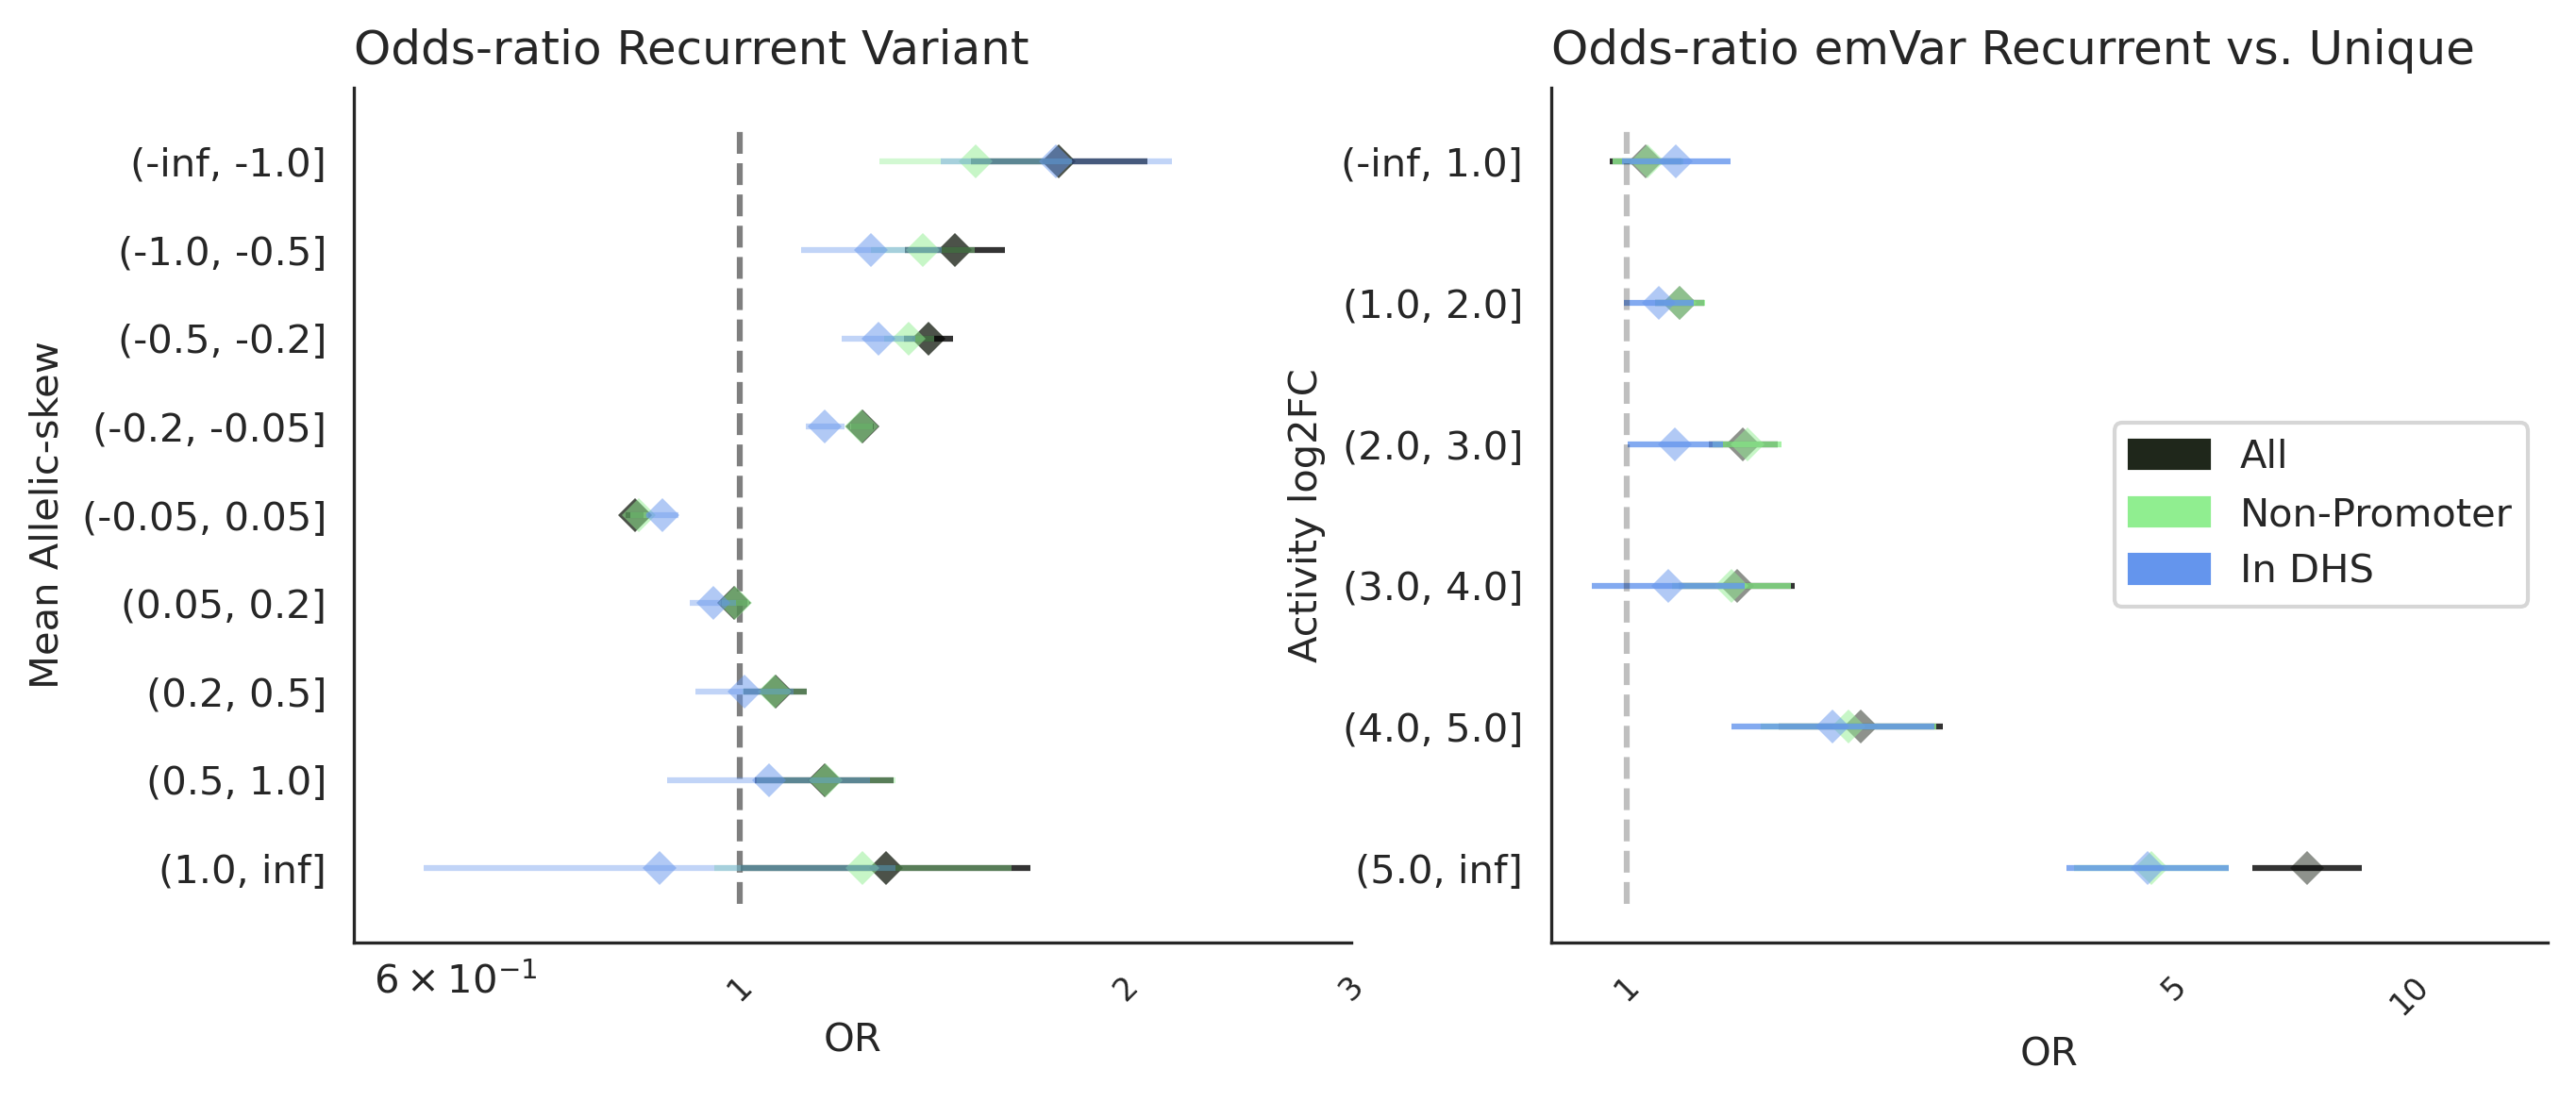

In [30]:
black_patch = mpatches.Patch(color="#1F271B", label='All')
green_patch = mpatches.Patch(color="lightgreen", label='Non-Promoter')
blue_patch = mpatches.Patch(color="cornflowerblue", label='In DHS')
# max ref | alt by cell type - binned by prediction with maximum skew
f = mpl.figure(dpi=300,figsize=(10,4))
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42
gs = f.add_gridspec(1, 2)
# mean allelic skew bins
with sns.axes_style("white"):
    ax0 = f.add_subplot(gs[0, 0])
    ax0.set_xscale('log')
    # plot all
    sns.pointplot(
    data=recurrent_oddsR_by_bin, x="OddsR", y="label",
    color="#1F271B", linestyle="none", marker="D", markersize=6, linewidth=0, alpha=.8
)
    for lower, upper, lab in zip(recurrent_oddsR_by_bin['lowerCI'],
                                 recurrent_oddsR_by_bin['upperCI'],
                                 recurrent_oddsR_by_bin['label']):
        mpl.hlines(xmin=lower, xmax=upper, y=lab, color='k', alpha=.8)
    ymin, ymax = ax0.get_ylim()
    mpl.vlines(x=1, ymin=ymin, ymax=ymax, color='k', alpha=.5, linestyle='dashed')
    # plot non-promoter
    sns.pointplot(
    data=recurrent_oddsR_by_bin_no_pro, x="OddsR", y="label",
    color="lightgreen", linestyle="none", marker="D", markersize=6, linewidth=0, alpha=.5
)
    for lower, upper, lab in zip(recurrent_oddsR_by_bin_no_pro['lowerCI'],
                                 recurrent_oddsR_by_bin_no_pro['upperCI'],
                                 recurrent_oddsR_by_bin_no_pro['label']):
        mpl.hlines(xmin=lower, xmax=upper, y=lab, color='lightgreen', alpha=.4)
    # plot in dhs
    sns.pointplot(
    data=recurrent_oddsR_by_bin_no_pro_in_dhs, x="OddsR", y="label",
    color="cornflowerblue", linestyle="none", marker="D", markersize=6, linewidth=0, alpha=.5,
)
    for lower, upper, lab in zip(recurrent_oddsR_by_bin_no_pro_in_dhs['lowerCI'],
                                 recurrent_oddsR_by_bin_no_pro_in_dhs['upperCI'],
                                 recurrent_oddsR_by_bin_no_pro_in_dhs['label']):
        mpl.hlines(xmin=lower, xmax=upper, y=lab, color='cornflowerblue', alpha=.4)
    mpl.title('Odds-ratio Recurrent Variant', loc='left')
    mpl.ylabel('Mean Allelic-skew')
    mpl.xlim(.5, 3)
    mpl.xticks([1, 2, 3], ['1','2','3'], rotation=45, size=8)
    mpl.xlabel('OR')
# recurrent by activity bin
with sns.axes_style("white"):
    ax1 = f.add_subplot(gs[0, 1])
    ax1.set_xscale('log')
    # all
    sns.pointplot(data=recurrent_emvar_or_by_act, x="OddsR", y="Bin",
    color="#1F271B", linestyle="none", marker="D", markersize=6, linewidth=0, alpha=.5)
    for lower, upper, lab in zip(recurrent_emvar_or_by_act['lowerCI'],
                                 recurrent_emvar_or_by_act['upperCI'],
                                 recurrent_emvar_or_by_act['label']):
        mpl.hlines(xmin=lower, xmax=upper, y=lab, color='k', alpha=.8)
    # non-promoter
    sns.pointplot(data=recurrent_emvar_or_by_act_no_pro, x="OddsR", y="Bin",
    color="lightgreen", linestyle="none", marker="D", markersize=6, linewidth=0, alpha=.5)
    for lower, upper, lab in zip(recurrent_emvar_or_by_act_no_pro['lowerCI'],
                                 recurrent_emvar_or_by_act_no_pro['upperCI'],
                                 recurrent_emvar_or_by_act_no_pro['label']):
        mpl.hlines(xmin=lower, xmax=upper, y=lab, color='lightgreen', alpha=.8)
    ymin, ymax = ax1.get_ylim()
    # in dhs
    sns.pointplot(data=recurrent_emvar_or_by_act_no_pro_in_dhs, x="OddsR", y="Bin",
    color="cornflowerblue", linestyle="none", marker="D", markersize=6, linewidth=0, alpha=.5)
    for lower, upper, lab in zip(recurrent_emvar_or_by_act_no_pro_in_dhs['lowerCI'],
                                 recurrent_emvar_or_by_act_no_pro_in_dhs['upperCI'],
                                 recurrent_emvar_or_by_act_no_pro_in_dhs['label']):
        mpl.hlines(xmin=lower, xmax=upper, y=lab, color='cornflowerblue', alpha=.8)
    ymin, ymax = ax1.get_ylim()
    mpl.vlines(x=1, ymin=ymin, ymax=ymax, color='k', alpha=.25, linestyle='dashed')
    mpl.title('Odds-ratio emVar Recurrent vs. Unique', loc='left')
    mpl.xlabel('OR')
    mpl.xlim(.8,15)
    mpl.xticks([1, 5, 10], ['1','5','10'], rotation=45, size=8)
    mpl.ylabel('Activity log2FC')
    mpl.legend(handles=[black_patch,
                        green_patch,
                        blue_patch], loc='center right')
sns.despine()
#mpl.savefig('/Users/buttsj/Dropbox (JAX)/Variant_Effects/final_plots_v2/cosmic/oddsR_recurrent_emvar_by_activity_bin_combined_with_skew_bin.pdf')

In [32]:
recurrent_emvar_or_by_act

,index,Feature,Bin,OddsR,p_val,round_p,upperCI,lowerCI,label,n_recurrent_emvars
3,0,emVar,"(-inf, 1.0]",1.057505,2.987818e-01,0.3,1.173876,0.952671,"(-inf, 1.0]",365
4,0,emVar,"(1.0, 2.0]",1.167930,4.411775e-05,0.0,1.256445,1.085652,"(1.0, 2.0]",752
5,0,emVar,"(2.0, 3.0]",1.408367,3.381033e-10,0.0,1.559221,1.272109,"(2.0, 3.0]",388
0,0,emVar,"(3.0, 4.0]",1.383000,3.274691e-04,0.0,1.639687,1.166497,"(3.0, 4.0]",138
2,0,emVar,"(4.0, 5.0]",1.990552,3.022441e-07,0.0,2.532737,1.564433,"(4.0, 5.0]",70
1,0,emVar,"(5.0, inf]",7.393350,8.624769e-85,0.0,8.686934,6.292396,"(5.0, inf]",179
